# Identyfikacja odcisku 
na podstawie dostępnych (w `Database/all`, a właściwie to w `Database/processed/processed_data.json`)

In [29]:
import json
from pathlib import Path
from utils import proces_image_and_get_points, compare_fingerprints, show
import cv2

all_fingerprints_path = Path('Database/processed/processed_data.json')
all_fingerprints_data = json.loads(open(all_fingerprints_path).read())

In [6]:
def identify_user(given_fingerprint_points, ):
    best_match = None
    best_score = -1

    for user_id, db_points in all_fingerprints_data.items():
        score, matched = compare_fingerprints(given_fingerprint_points, db_points)
        if score > best_score:
            best_score = score
            best_match = user_id

    return best_score, best_match

In [36]:
def perform_identification(given_fingerprint_path_str):
    given_fingerprint_path = Path(given_fingerprint_path_str)
    given_fingerprint_points = proces_image_and_get_points(given_fingerprint_path)

    print("\tCechy podanego odcisku palca:")
    print("\t", given_fingerprint_points)
    best_score, best_match = identify_user(given_fingerprint_points)
    print()

    if (best_score > (len(given_fingerprint_points)/2)):
        print("\tZidentyfikowano uzytkownika jako: "+best_match+" z wynikiem: "+str(best_score))
        fingerprint1 = cv2.imread(given_fingerprint_path, cv2.IMREAD_GRAYSCALE)
        fingerprint2 = cv2.imread(Path("Database/all/"+best_match+".tif"), cv2.IMREAD_GRAYSCALE)
        # show(fingerprint1, 'Podany odcisk')
        # show(fingerprint2, 'Dopasowany odcisk')
        print('\t(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk')
        show(fingerprint1, fingerprint2)
    else:
        print("\tUżytkownik nieznany lub odcisk jest niewystarczająco dobry")


Testowany odcisk: DB1_B/101_1.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (196, 266), 'index': np.float32(-180.0)}]

	Zidentyfikowano uzytkownika jako: 1_1 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

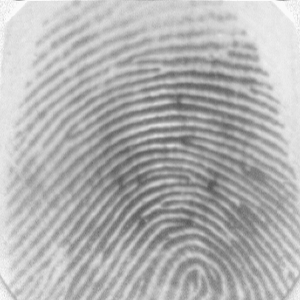
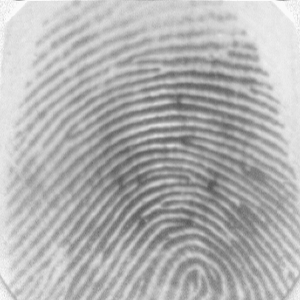



Testowany odcisk: DB1_B/101_2.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (176, 246), 'index': np.float32(-180.0)}]

	Zidentyfikowano uzytkownika jako: 1_2 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

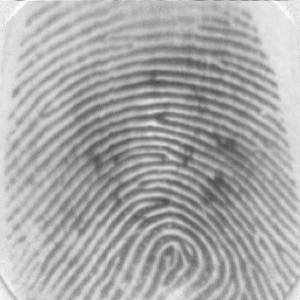
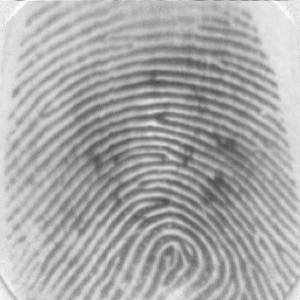



Testowany odcisk: DB1_B/101_3.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (216, 286), 'index': np.float32(-180.0)}]

	Zidentyfikowano uzytkownika jako: 1_3 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

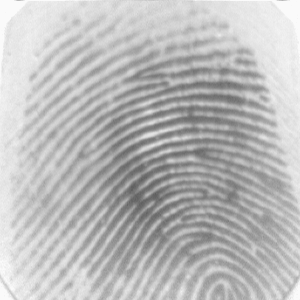
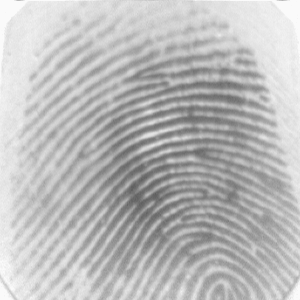



Testowany odcisk: DB1_B/101_4.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (266, 156), 'index': np.float32(-180.0)}]

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry


Testowany odcisk: DB1_B/101_5.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (196, 246), 'index': np.float32(-179.99998)}]

	Zidentyfikowano uzytkownika jako: 1_5 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

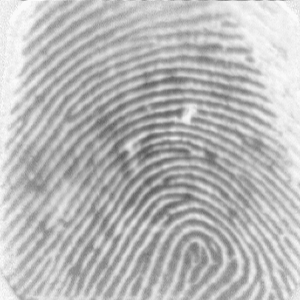
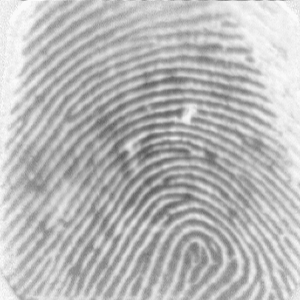



Testowany odcisk: DB1_B/101_6.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (196, 236), 'index': np.float32(-180.00002)}]

	Zidentyfikowano uzytkownika jako: 1_6 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

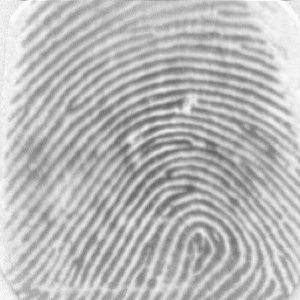
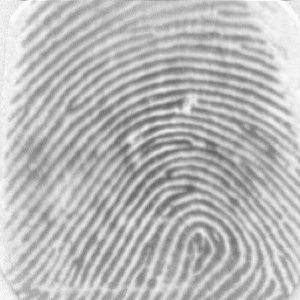



Testowany odcisk: DB1_B/101_7.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (196, 186), 'index': np.float32(-180.0)}, {'type': 'delta', 'coords': (276, 256), 'index': np.float32(180.0)}, {'type': 'core', 'coords': (16, 286), 'index': np.float32(-180.0)}]

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry


Testowany odcisk: DB1_B/101_8.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (206, 266), 'index': np.float32(-179.99998)}]

	Zidentyfikowano uzytkownika jako: 1_8 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

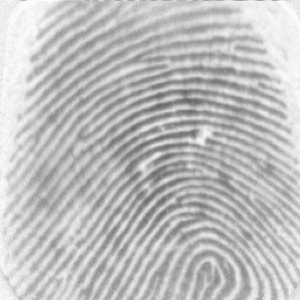
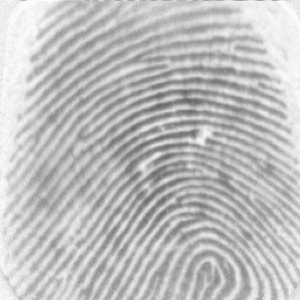

In [37]:
paths_str = ['DB1_B/101_1.tif', 'DB1_B/101_2.tif', 'DB1_B/101_3.tif', 'DB1_B/101_4.tif', 'DB1_B/101_5.tif', 'DB1_B/101_6.tif', 'DB1_B/101_7.tif', 'DB1_B/101_8.tif']
for path_str in paths_str:
    print("Testowany odcisk: "+path_str)
    perform_identification(path_str)
    print("\n")

# print("Inne odciski użytkownika: ")